# CUSTOMER DATA 

In [1]:
# import libraries in python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET

In [4]:
data = pd.read_csv('archive/customer_segmentation_data.csv')
df= pd.DataFrame(data)

### CLEANING DATASET

In [5]:
df.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [6]:
df.tail()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16
999,1000,36,Female,90420,7,2,31,Groceries,669.26


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [8]:
df.columns

Index(['id', 'age', 'gender', 'income', 'spending_score', 'membership_years',
       'purchase_frequency', 'preferred_category', 'last_purchase_amount'],
      dtype='object')

In [11]:
df.size

9000

In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.duplicated().value_counts()

False    1000
Name: count, dtype: int64

In [16]:
df.isnull()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [17]:
df.isnull().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [20]:
df.isnull().value_counts()

id     age    gender  income  spending_score  membership_years  purchase_frequency  preferred_category  last_purchase_amount
False  False  False   False   False           False             False               False               False                   1000
Name: count, dtype: int64

In [21]:
df.isnull().value_counts().sum()

np.int64(1000)

In [22]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [25]:
df[['age','income','last_purchase_amount']].describe()

,age,income,last_purchase_amount
count,1000.000000,1000.000000,1000.000000
mean,43.783000,88500.800000,492.348670
std,15.042213,34230.771122,295.744253
min,18.000000,30004.000000,10.400000
25%,30.000000,57911.750000,218.762500
50%,45.000000,87845.500000,491.595000
75%,57.000000,116110.250000,747.170000
max,69.000000,149973.000000,999.740000


In [33]:
df[df['gender'].isin(['Male'])]

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
7,8,43,Male,108115,94,9,27,Groceries,734.56
8,9,53,Male,34424,29,6,7,Sports,951.71
14,15,33,Male,112260,17,5,8,Home & Garden,915.89
15,16,53,Male,129284,17,6,26,Clothing,225.40
16,17,57,Male,102535,29,5,13,Clothing,378.47
...,...,...,...,...,...,...,...,...,...
987,988,26,Male,148451,78,5,14,Groceries,99.19
988,989,26,Male,45147,93,1,32,Home & Garden,750.58
994,995,60,Male,71923,25,2,40,Clothing,986.97
995,996,57,Male,112170,57,6,1,Clothing,313.64


In [31]:
df['gender'].isin(['Male']).sum()

np.int64(357)

In [33]:
df['gender'].isin(['Female']).sum()

np.int64(316)

In [41]:
df.groupby('gender').agg({'gender':'count'})

,gender
gender,
Female,316
Male,357
Other,327


In [42]:
df.head(3)

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36


In [48]:
df[df['purchase_frequency'] >=0].groupby('gender')['purchase_frequency'].sum()


gender
Female     8034
Male      10104
Other      8458
Name: purchase_frequency, dtype: int64

In [51]:
df['preferred_category'].value_counts()

preferred_category
Electronics      215
Sports           210
Home & Garden    206
Groceries        199
Clothing         170
Name: count, dtype: int64

# DATA EXPLONATORY DATA ANALAYSIS [ EDA ]

In [53]:
df.shape

(1000, 9)

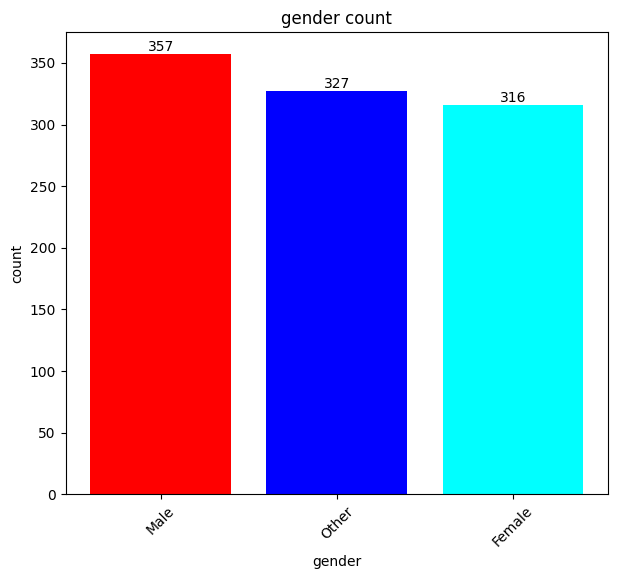

In [64]:
# groupby gender of count
gender_count = df['gender'].value_counts()

# create a figure and axis
fig,sa =plt.subplots(figsize=(7,6))

# define the color using the graphs 
colors =['red','blue','cyan']

# create a barplot
bar = sa.bar(gender_count.index,gender_count.values,color=colors[:len(gender_count)])

# adding a bar label
sa.bar_label(bar)

# add a title of label and axis

sa.set_title('gender count')
sa.set_xlabel('gender')
sa.set_ylabel('count')

# optional: rotation of x axis label its needed
plt.xticks(rotation= 45)

# show the graphs
plt.show()             

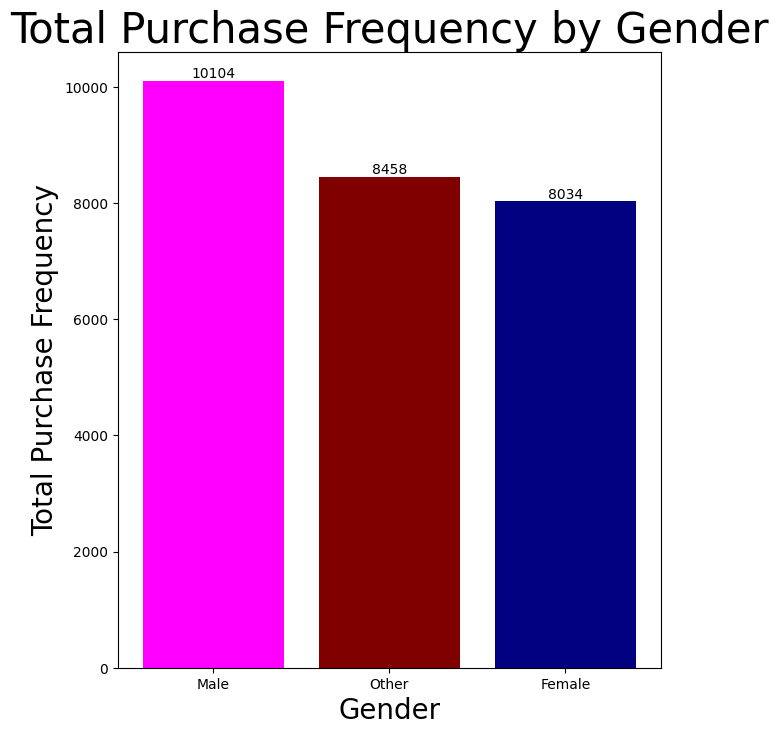

In [95]:
# purchase_frequency groupby the gender
gender_purchase = df.groupby('gender')['purchase_frequency'].sum().sort_values(ascending=False)

# create a figure and axis
fig,sa=plt.subplots(figsize=(7,8))

# define the color using the bar graphs
colors = ['Magenta', 'Maroon', 'Navy']

#  create a bar plot 
bar = sa.bar(gender_purchase.index,gender_purchase.values,color=colors[:len(gender_purchase)])

# adding a bar label
sa.bar_label(bar)

# adding a title and axis label
sa.set_title('Total Purchase Frequency by Gender',fontsize=30)
sa.set_xlabel('Gender',fontsize=20)
sa.set_ylabel('Total Purchase Frequency',fontsize=20)

# show the graphs 
plt.show()

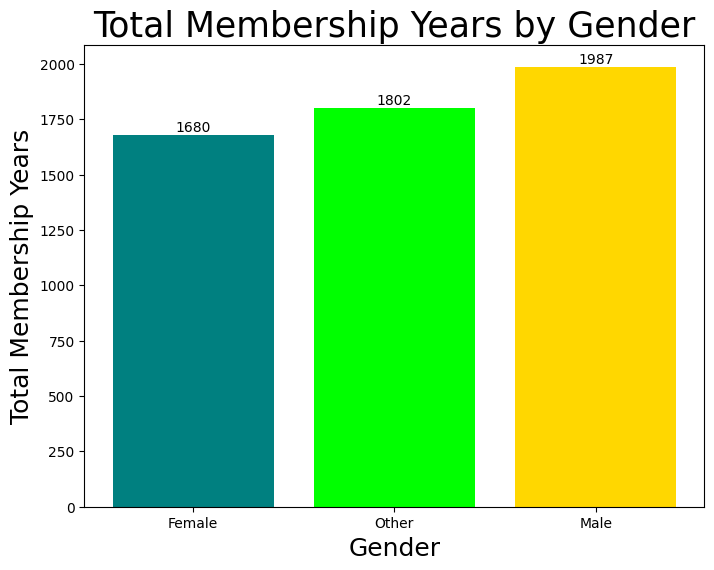

In [93]:
# membership_year grouping by the gender
gender_membership = df.groupby('gender')['membership_years'].sum().sort_values()

# create figure and axis
fig,sa=plt.subplots(figsize=(8,6))

# define the color unsing the diagrma
colors = ['Teal','Lime','Gold']

# create a bar plot
bar= sa.bar(gender_membership.index,gender_membership.values,color=colors[:len(gender_membership)])

# adding a bar label
sa.bar_label(bar)

# adding a title and axis label
sa.set_title('Total Membership Years by Gender',fontsize=25)  # Graph ka title
sa.set_xlabel('Gender',fontsize=18)                           # X-axis label
sa.set_ylabel('Total Membership Years',fontsize=18)           # Y-axis label

# show the graphs
plt.show()

In [90]:
np.sort(df['age'].unique()) 

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69])

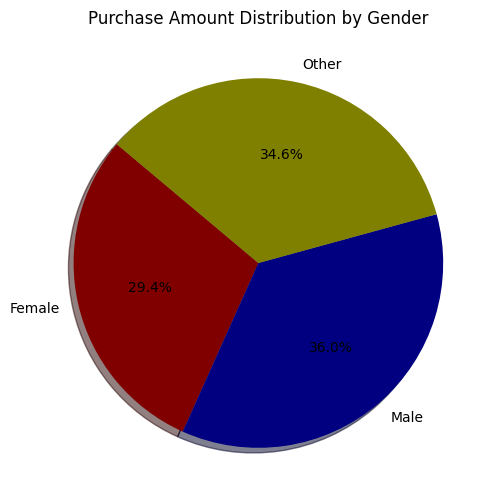

In [99]:
# gender ke hisaab se total purchase amount
gender_purchase = df.groupby('gender')['last_purchase_amount'].sum()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(gender_purchase.values, labels=gender_purchase.index, 
        autopct='%1.1f%%', colors=['Maroon', 'Navy', 'Olive'], startangle=140,shadow=True)

# adding a title of pie chart
plt.title('Purchase Amount Distribution by Gender')

# show the graphs
plt.show()

In [101]:
df.head(2)

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93


# If I want to calculate the minimum, maximum, and mean income by gender

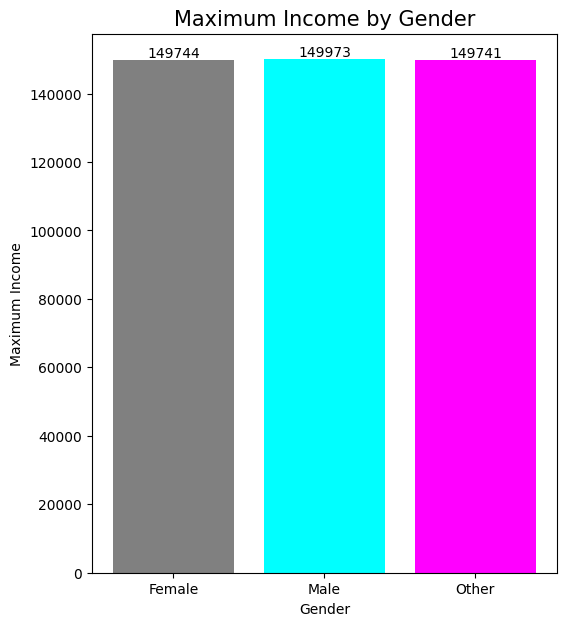

In [109]:
# gender ke hisab se income ma maximum value
income_maximum_gender =df.groupby('gender')['income'].max()

# create figure and axis
fig,sa=plt.subplots(figsize=(6,7))

# define the color using the graphs
color = ['Gray', 'Cyan', 'Magenta']

#create a barplot
bar=sa.bar(income_maximum_gender.index,income_maximum_gender.values,color=color[:len(income_maximum_gender)])

# adding a bar label
sa.bar_label(bar)

# adding a title and label of graphs
sa.set_title('Maximum Income by Gender',fontsize=15)
sa.set_xlabel('Gender',fontsize=10)
sa.set_ylabel('Maximum Income',fontsize=10)

# show the graphs
plt.show()

In [55]:
df['age'].value_counts().head(10).sort_index()

age
19    28
30    30
33    29
41    25
45    29
47    32
53    28
61    24
64    27
69    28
Name: count, dtype: int64

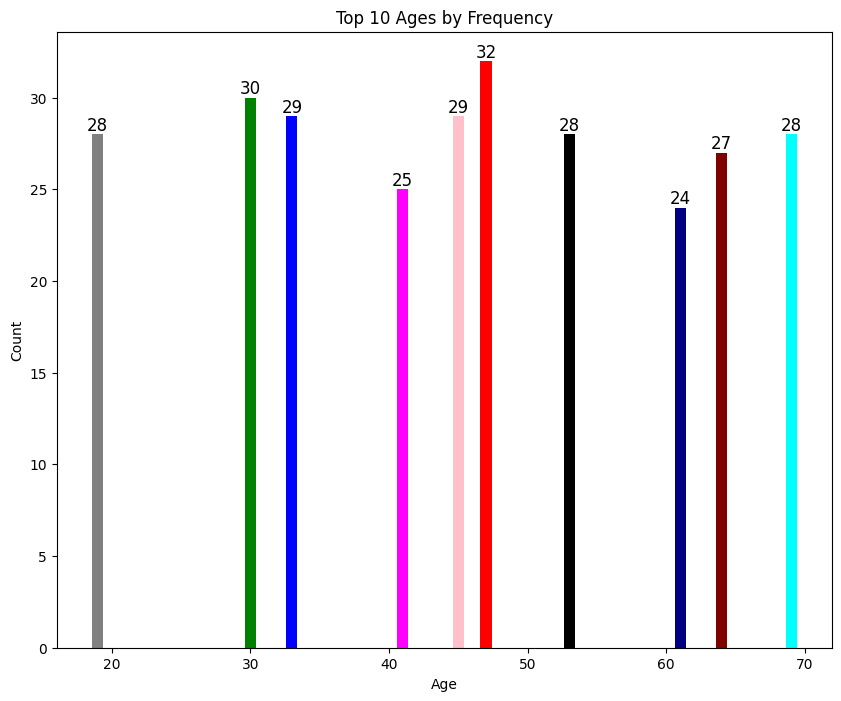

In [48]:
 # top 10 ages by frequency
top_ages = df['age'].value_counts().head(10)

# colors
colors = ['red','green','blue','pink','cyan','grey','black','maroon','magenta','navy']

# plot
fig, sa = plt.subplots(figsize=(10, 8))
bars = sa.bar(top_ages.index, top_ages.values, color=colors[:len(top_ages)])

# labels & title
sa.set_title("Top 10 Ages by Frequency")
sa.set_xlabel("Age")
sa.set_ylabel("Count")

# show labels inside bars (center)
sa.bar_label(bars, label_type="edge", color="black", fontsize=12)

plt.show()


In [59]:
df.groupby('gender')['income'].sum()

gender
Female    27813721
Male      31740155
Other     28946924
Name: income, dtype: int64

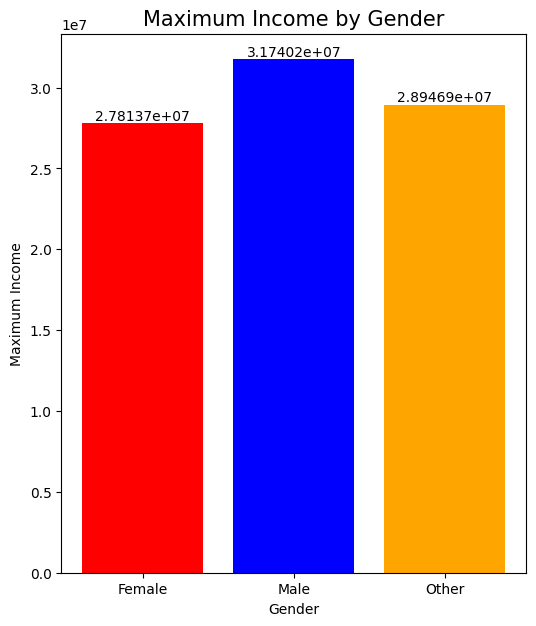

In [61]:
# gender ke hisab se income ma maximum value
income_maximum_gender =df.groupby('gender')['income'].sum()

# create figure and axis
fig,sa=plt.subplots(figsize=(6,7))

# define the color using the graphs
color = ['red','blue','orange']

#create a barplot
bar=sa.bar(income_maximum_gender.index,income_maximum_gender.values,color=color[:len(income_maximum_gender)])

# adding a bar label
sa.bar_label(bar)

# adding a title and label of graphs
sa.set_title('Maximum Income by Gender',fontsize=15)
sa.set_xlabel('Gender',fontsize=10)
sa.set_ylabel('Maximum Income',fontsize=10)

# show the graphs
plt.show()